# FFT / DCT Image Processing Basics

This notebook compares FFT and DCT based image processing.

## Goals

- Load and visualize images
- Convert images to YCrCb color space
- Focus on the Y (luminance) channel
- Analyze FFT frequency spectrum
- Analyze DCT coefficients
- Reconstruct the Y channel using IFFT / IDCT
- Experiment with frequency-domain processing on the Y channel

In [87]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.fft import dctn, idctn


import os

print(os.getcwd())

d:\Works\projects\Private\FrequencyVisionLab\notebooks


In [88]:
IMAGE_PATHS = [
    "imgs/test0.jpg",
    "imgs/test1.jpg",
]

images = []

for path in IMAGE_PATHS:
    image = cv2.imread(path)

    if image is None:
        raise FileNotFoundError(path)

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ycrcb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2YCrCb
    )

    y, cr, cb = cv2.split(ycrcb)

    images.append({
        "path": path,
        "bgr": image,
        "rgb": rgb,
        "ycrcb": ycrcb,
        "y": y,
        "cr": cr,
        "cb": cb,
    })

# Display Original Images 

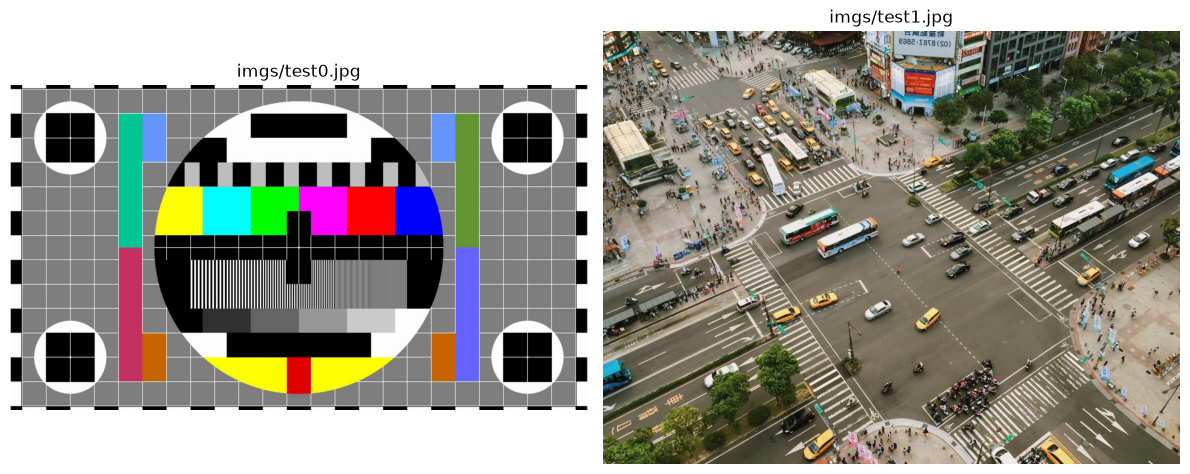

In [89]:
# Display input images (2 images per row)
for i in range(0, len(images), 2):
    plt.figure(figsize=(12, 5))

    # First image
    plt.subplot(1, 2, 1)
    plt.imshow(images[i]["rgb"])
    plt.title(images[i]["path"])
    plt.axis("off")

    # Second image
    if i + 1 < len(images):
        plt.subplot(1, 2, 2)
        plt.imshow(images[i + 1]["rgb"])
        plt.title(images[i + 1]["path"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# FFT

The Fast Fourier Transform converts image data from the spatial domain into the frequency domain.

After applying `fftshift()`, low-frequency components are located near the center of the spectrum.

In [90]:
# FFT: Spatial Domain → Frequency Domain
def fft_analysis(image):
    # image:
    #   입력 영상의 Y(Luminance) 채널
    #
    # fft2():
    #   2D Fast Fourier Transform 수행
    #   공간 영역의 영상을 복소수 주파수 영역으로 변환
    #
    # fftshift():
    #   FFT 결과의 저주파 성분을 중앙으로 이동
    #   spectrum을 보기 쉽게 재배치
    #
    # np.abs():
    #   복소수 FFT 결과에서 magnitude 계산
    #
    # np.log1p():
    #   큰 dynamic range를 로그 스케일로 줄여
    #   주파수 spectrum을 시각화하기 쉽게 만듦    
    fft = np.fft.fft2(image)

    fft_shift = np.fft.fftshift(fft)

    magnitude = np.log1p(
        np.abs(fft_shift)
    )

    return fft_shift, magnitude

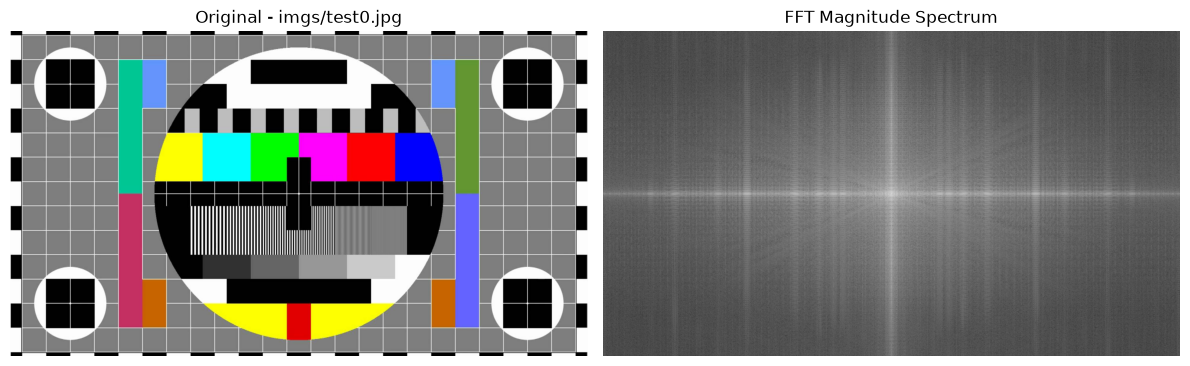

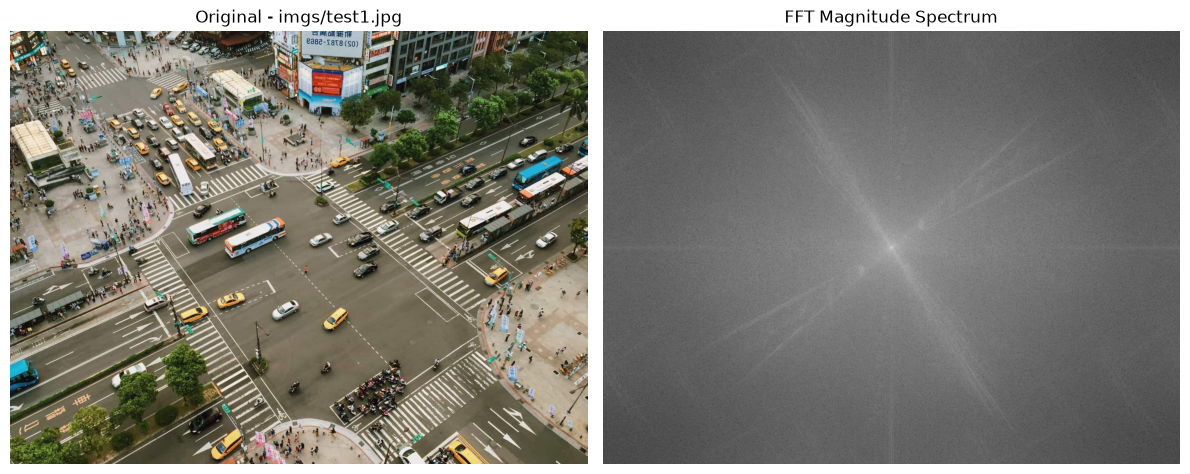

In [91]:
# Display FFT magnitude spectrum for each image
# Display original image and FFT magnitude spectrum
for item in images:
    fft_shift, magnitude = fft_analysis(
        item["y"]
    )

    plt.figure(figsize=(12, 5))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(
        item["rgb"]
    )
    plt.title(
        f"Original - {item['path']}"
    )
    plt.axis("off")

    # FFT magnitude spectrum
    plt.subplot(1, 2, 2)
    plt.imshow(
        magnitude,
        cmap="gray"
    )
    plt.title(
        "FFT Magnitude Spectrum"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## FFT Reconstruction (IFFT)

No frequency components are modified in this experiment.

The original image is reconstructed using IFFT.

In [92]:
# IFFT: Frequency Domain → Spatial Domain
def fft_reconstruct(fft_shift):
    # fft_shift:
    #   fftshift()가 적용된 주파수 영역 데이터
    #
    # ifftshift():
    #   중앙으로 이동시킨 저주파 성분을
    #   원래 FFT 배열 위치로 복원
    #
    # ifft2():
    #   2D Inverse Fast Fourier Transform
    #   주파수 영역 데이터를 공간 영역 영상으로 복원
    #
    # np.real():
    #   IFFT 결과는 복소수 형태로 반환될 수 있으므로
    #   실제 영상에 필요한 실수 성분만 사용    
    fft_ishift = np.fft.ifftshift(
        fft_shift
    )

    reconstructed = np.fft.ifft2(
        fft_ishift
    )

    return np.real(reconstructed)

# FFT Original vs IFFT (Reconstruction)

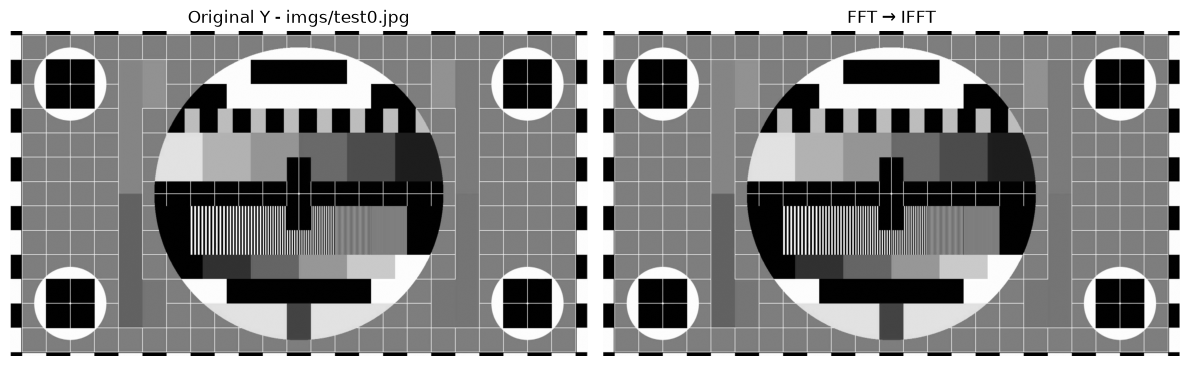

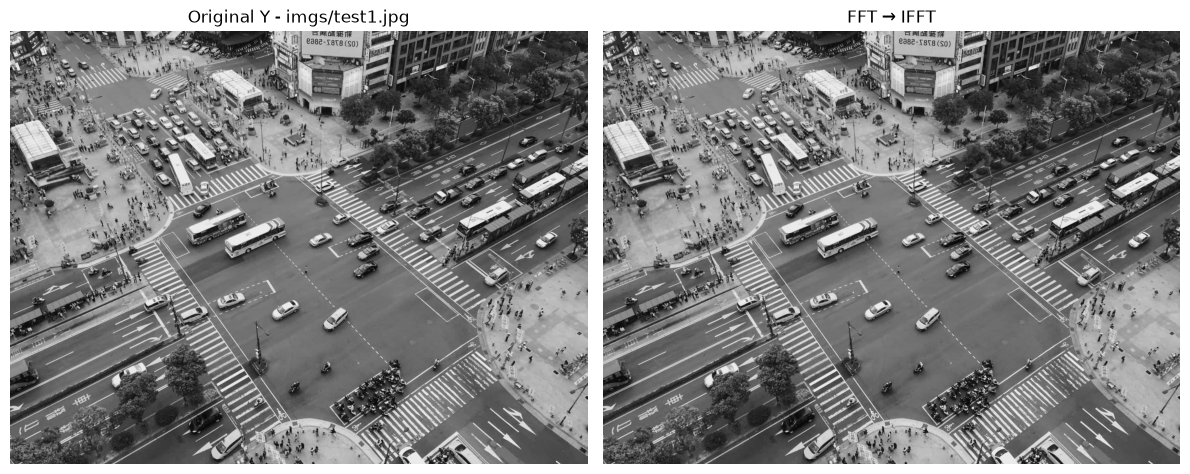

In [93]:
for item in images:
    # Grayscale FFT analysis because of only Y channel
    fft_shift, _ = fft_analysis(
        item["y"]
    )

    # Inverse FFT reconstruction
    reconstructed = fft_reconstruct(
        fft_shift
    )

    plt.figure(figsize=(12, 5))

    # Left: Original Y
    plt.subplot(1, 2, 1)
    plt.imshow(
        item["y"],
        cmap="gray"
    )
    plt.title(
        f"Original Y - {item['path']}"
    )
    plt.axis("off")

    # Right: FFT -> IFFT
    plt.subplot(1, 2, 2)
    plt.imshow(
        reconstructed,
        cmap="gray"
    )
    plt.title(
        "FFT → IFFT"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# DCT

The Discrete Cosine Transform converts spatial image data into real-valued frequency coefficients.

Unlike FFT, DCT uses cosine basis functions only.

Low-frequency coefficients are located near the upper-left corner.

In [94]:
def dct_analysis(image):
    # DCT: Spatial Domain → Frequency Domain
    #
    # image:
    #   입력 영상의 Y(Luminance) 채널
    #
    # astype(np.float32):
    #   DCT 연산을 위해 uint8 영상을 float 형식으로 변환
    #
    # dctn():
    #   N-dimensional Discrete Cosine Transform
    #
    # type=2:
    #   DCT-II 사용
    #
    # norm="ortho":
    #   Orthonormal normalization 적용
    #   IDCT 수행 시 별도의 scaling 없이 원본 신호 복원이 용이
    #
    # magnitude:
    #   DCT coefficient의 크기를 로그 스케일로 변환
    #   주파수 성분을 시각화하기 쉽게 만듦    
    image_float = image.astype(
        np.float32
    )

    coefficients = dctn(
        image_float,
        type=2,
        norm="ortho"
    )

    magnitude = np.log1p(
        np.abs(coefficients)
    )

    return coefficients, magnitude

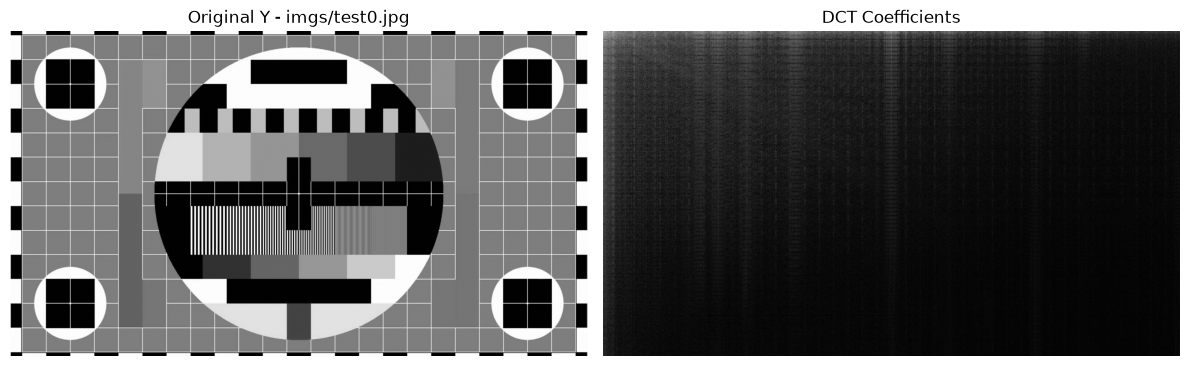

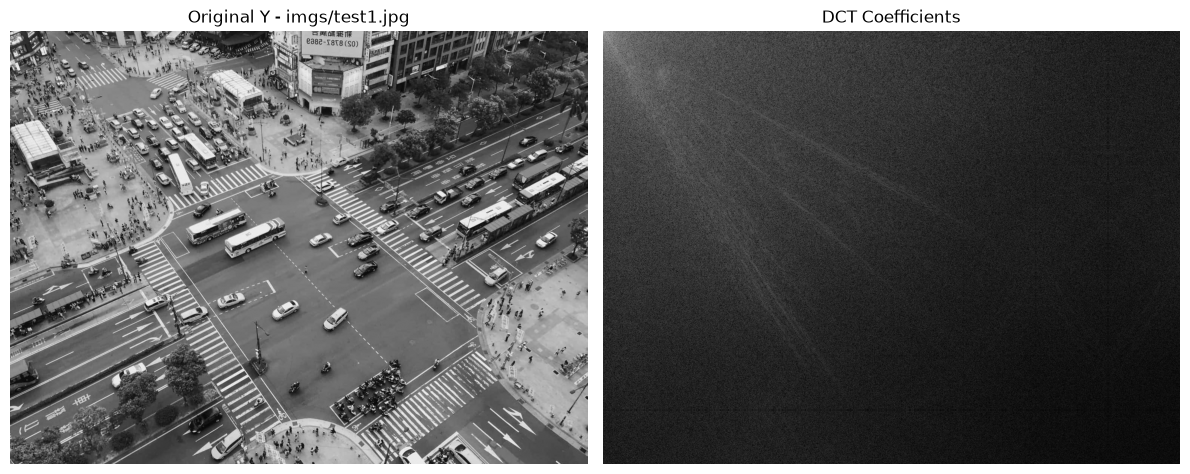

In [95]:
for item in images:
    coefficients, magnitude = dct_analysis(
        item["y"]
    )

    plt.figure(figsize=(12, 5))

    # Left: Original Y
    plt.subplot(1, 2, 1)
    plt.imshow(
        item["y"],
        cmap="gray"
    )
    plt.title(
        f"Original Y - {item['path']}"
    )
    plt.axis("off")

    # Right: DCT coefficients
    plt.subplot(1, 2, 2)
    plt.imshow(
        magnitude,
        cmap="gray"
    )
    plt.title(
        "DCT Coefficients"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## DCT Reconstruction

The DCT coefficients are reconstructed using IDCT without modification.

In [96]:
def dct_reconstruct(coefficients):
    # IDCT (Inverse Discrete Cosine Transform)
    #
    # coefficients:
    #   DCT를 통해 얻은 주파수 계수
    #
    # type=2:
    #   DCT-II에 대응하는 inverse transform을 수행
    #
    # norm="ortho":
    #   Orthonormal normalization 사용
    #   별도의 scaling 없이 원본 신호에 가깝게 복원 가능    
    reconstructed = idctn(
        coefficients,
        type=2,
        norm="ortho"
    )

    return reconstructed

# DCT Original vs IDCT (Reconstruction)

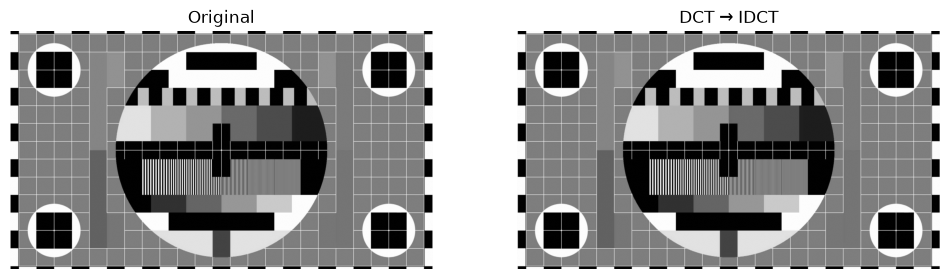

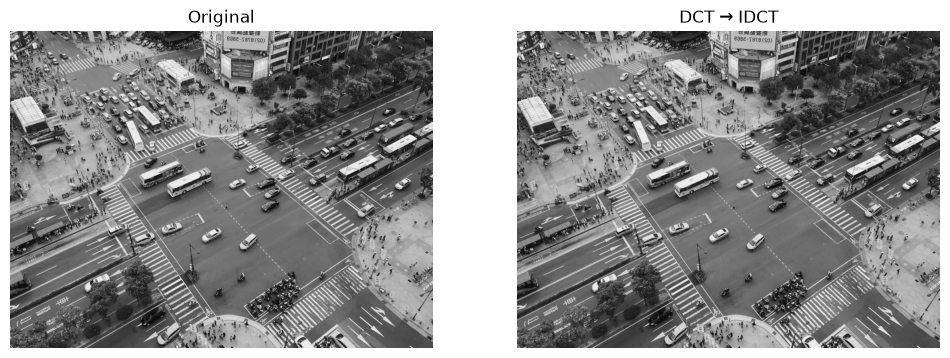

In [97]:
for item in images:
    coefficients, _ = dct_analysis(
        item["y"]
    )

    reconstructed = dct_reconstruct(
        coefficients
    )

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(
        item["y"],
        cmap="gray"
    )
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(
        reconstructed,
        cmap="gray"
    )
    plt.title("DCT → IDCT")
    plt.axis("off")

    plt.show()

# FFT vs DCT

| Feature | FFT | DCT |
|---|---|---|
| Coefficients | **Complex** | **Real** |
| Basis | Sine + Cosine | Cosine |
| Low Frequency Position | Center after `fftshift()` | Upper-left |
| Phase Information | **Available** | No explicit phase |
| Reconstruction | IFFT | IDCT |
| Typical Use | Frequency analysis | **Compression / frequency processing** |

## Initial Observation

Both FFT and DCT can represent image information in the frequency domain.

FFT explicitly provides magnitude and phase information.

DCT concentrates image energy into low-frequency coefficients and is widely used in image and video compression.

No filtering has been applied yet.

The next experiment will apply:

- Low-Pass Filter
- High-Pass Filter
- Band-Pass Filter 
- Frequency component reduction